### [New Advanced Python Charts](https://andymcdonaldgeo.medium.com/3-python-charts-youre-probably-not-using-but-should-be-e69199f7d784)

> Three underused chart types and when to reach for them when working with well log data

In [1]:
import sys
import subprocess

def install_missing(package, import_name=None):
    """Install package if not already available."""
    import_name = import_name or package.split('[')[0]  # handle extras like langchain[google]
    try:
        __import__(import_name.replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_missing("bumplot")
install_missing("joypy")
print("✓ All packages ready!")

Installing bumplot...
Installing joypy...
✓ All packages ready!


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joypy
from bumplot import bumplot

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [3]:
years = [2019, 2020, 2021, 2022, 2023]

measurements = {
    'Well A': [1, 2, 1, 1, 2],
    'Well B': [2, 1, 2, 3, 1],
    'Well C': [3, 3, 4, 2, 3],
    'Well D': [4, 4, 3, 4, 4],
    'Well E': [5, 6, 5, 5, 6],
    'Well F': [7, 5, 6, 7, 5],
    'Well G': [6, 7, 7, 6, 7],
}

display(pd.DataFrame(measurements))

,Well A,Well B,Well C,Well D,Well E,Well F,Well G
0,1,2,3,4,5,7,6
1,2,1,3,4,6,5,7
2,1,2,4,3,5,6,7
3,1,3,2,4,5,7,6
4,2,1,3,4,6,5,7


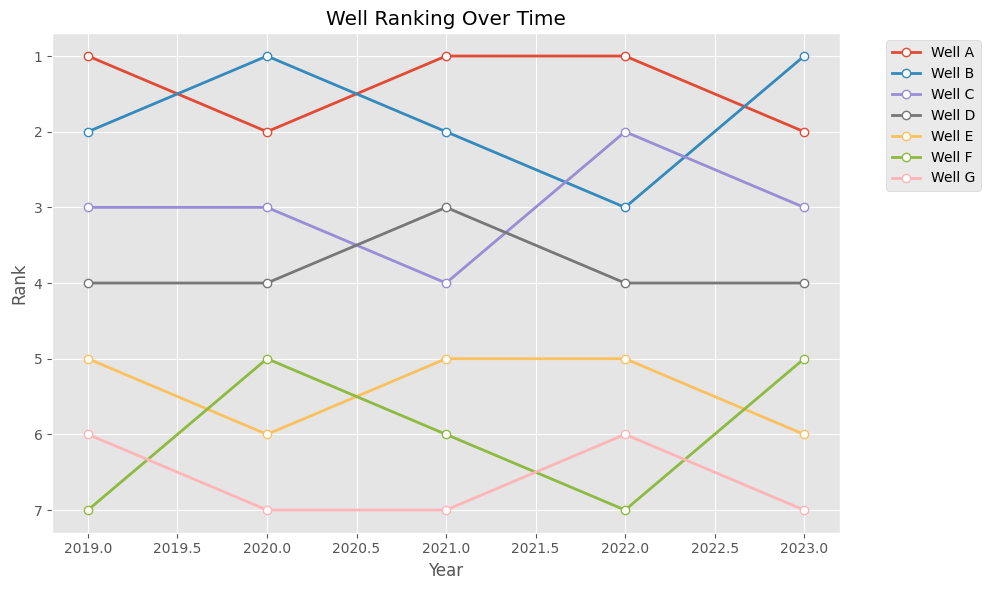

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for measurement, ranks in measurements.items():
    ax.plot(years, ranks, marker='o', label=measurement,
            markerfacecolor='white', linewidth=2)
ax.set_ylabel('Rank')
ax.set_xlabel('Year')
ax.set_title('Well Ranking Over Time')
ax.invert_yaxis()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_yticks(range(1, 8))
plt.tight_layout()
plt.show()

In [5]:
df_bump = pd.DataFrame(measurements, index=years)
df_bump.index.name = 'Year'
df_ranked = df_bump.rank(axis=1, method='min').astype(int)

display(df_bump)

print()

display(df_ranked)

,Well A,Well B,Well C,Well D,Well E,Well F,Well G
Year,,,,,,,
2019,1,2,3,4,5,7,6
2020,2,1,3,4,6,5,7
2021,1,2,4,3,5,6,7
2022,1,3,2,4,5,7,6
2023,2,1,3,4,6,5,7


,Well A,Well B,Well C,Well D,Well E,Well F,Well G
Year,,,,,,,
2019,1,2,3,4,5,7,6
2020,2,1,3,4,6,5,7
2021,1,2,4,3,5,6,7
2022,1,3,2,4,5,7,6
2023,2,1,3,4,6,5,7


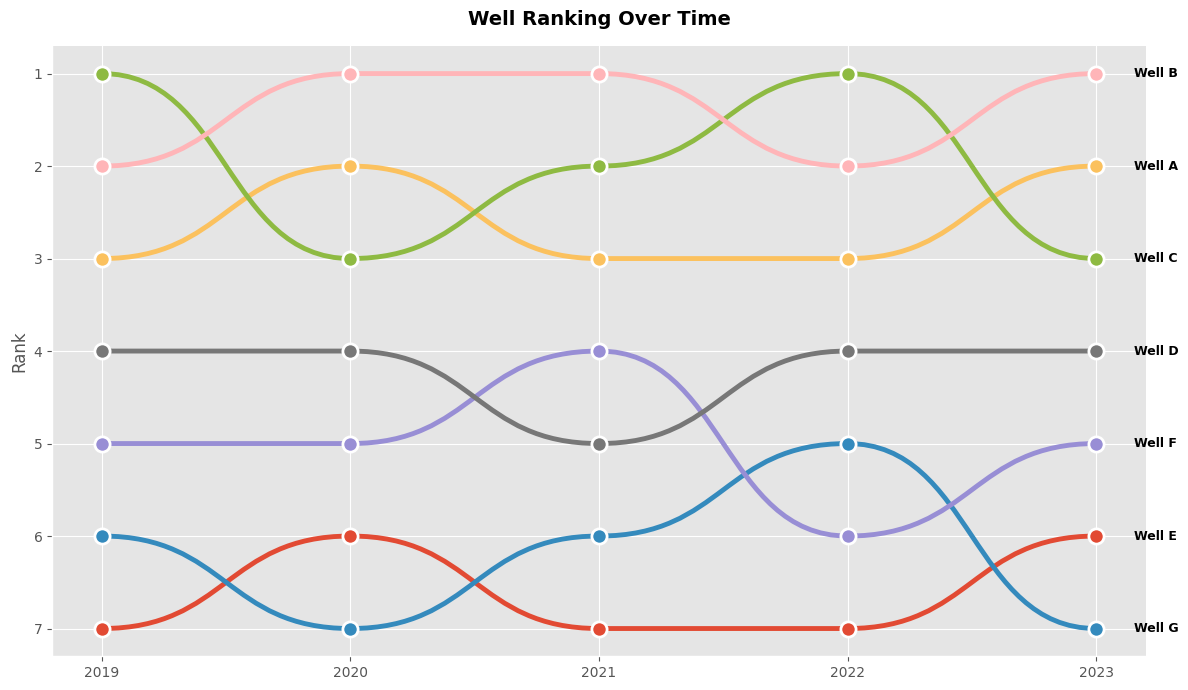

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
bumplot(
    x='Year',
    y_columns=list(measurements.keys()),
    data=df_ranked.reset_index(),
    curve_force=0.5,
    plot_kwargs={'lw': 3.5},
    scatter_kwargs={'s': 120, 'ec': 'white', 'lw': 2, 'zorder': 5},
)
ax.set_yticks(range(1, 8))
ax.set_ylabel('Rank', fontsize=12)
ax.set_xlabel('')
ax.set_title('Well Ranking Over Time',
             fontsize=14, fontweight='bold', pad=15)
for measurement, ranks in measurements.items():
    ax.text(2023.15, ranks[-1], measurement,
            va='center', fontsize=9, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
formations = {
    'Balder Fm': np.random.normal(loc=45, scale=12, size=500),
    'Sele Fm': np.random.normal(loc=85, scale=15, size=500),
    'Lista Fm': np.random.normal(loc=70, scale=20, size=500),
    'Tor Fm': np.random.normal(loc=25, scale=8, size=500),
    'Draupne Fm': np.random.normal(loc=110, scale=18, size=500),
    'Heather Fm': np.random.normal(loc=65, scale=22, size=500),
}
df_ridge = pd.DataFrame({
    'GR': np.concatenate(list(formations.values())),
    'Formation': np.concatenate([[name] * len(values)
                                  for name, values in formations.items()])
})

display(df_ridge)

,GR,Formation
0,50.9606,Balder Fm
1,43.3408,Balder Fm
2,52.7723,Balder Fm
3,63.2764,Balder Fm
4,42.1902,Balder Fm
...,...,...
2995,66.7046,Heather Fm
2996,70.6706,Heather Fm
2997,37.6813,Heather Fm
2998,72.3519,Heather Fm


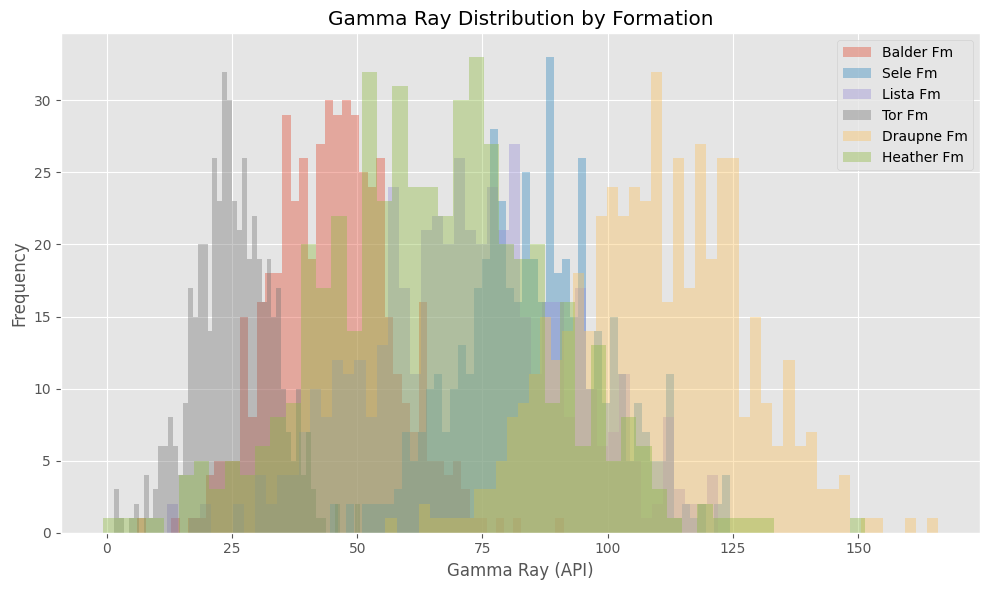

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for formation in formations:
    subset = df_ridge[df_ridge['Formation'] == formation]
    ax.hist(subset['GR'], bins=50, alpha=0.4, label=formation)
ax.set_xlabel('Gamma Ray (API)')
ax.set_ylabel('Frequency')
ax.set_title('Gamma Ray Distribution by Formation')
ax.legend()
plt.tight_layout()
plt.show()

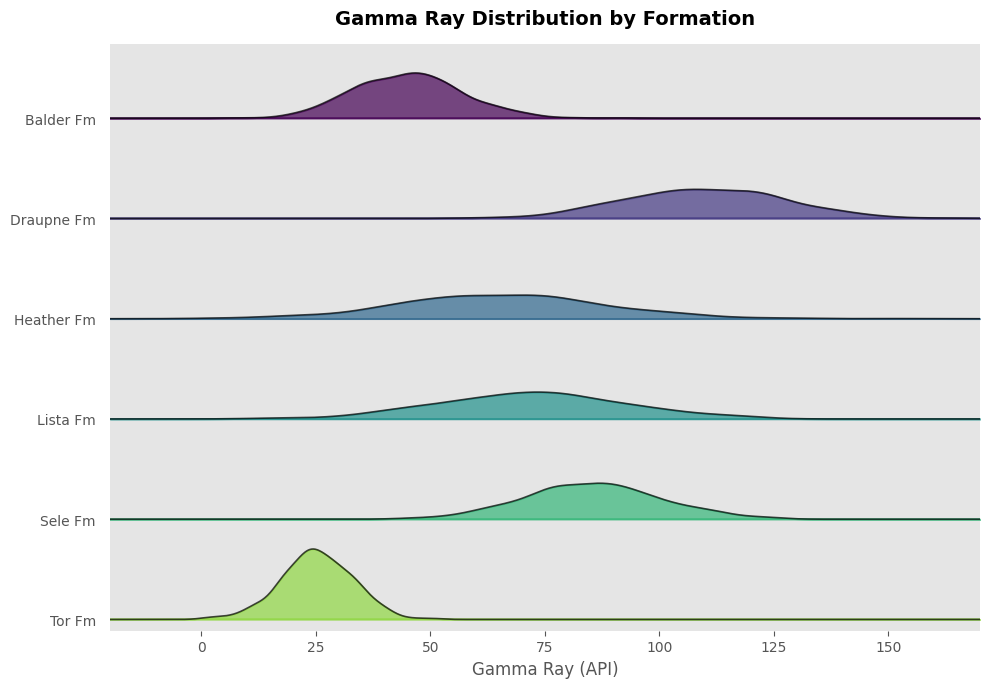

In [9]:
fig, axes = joypy.joyplot(
    df_ridge,
    by='Formation',
    column='GR',
    figsize=(10, 7),
    colormap=plt.cm.viridis,
    alpha=0.7,
    linewidth=1.2,
    overlap=0.4,
    x_range=(-20, 170),
)
plt.xlabel('Gamma Ray (API)', fontsize=12)
plt.title('Gamma Ray Distribution by Formation',
          fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
lithologies = {
    'Sandstone': np.random.normal(loc=22, scale=4, size=30),
    'Limestone': np.random.normal(loc=12, scale=3, size=25),
    'Dolomite': np.random.normal(loc=8, scale=2.5, size=20),
    'Shale': np.random.normal(loc=5, scale=2, size=35),
}

df_swarm = pd.DataFrame({
    'Porosity (%)': np.concatenate(list(lithologies.values())),
    'Lithology': np.concatenate([[name] * len(values)
                                  for name, values in lithologies.items()])
})

df_swarm['Porosity (%)'] = df_swarm['Porosity (%)'].clip(lower=0, upper=35)
display(df_swarm)

,Porosity (%),Lithology
0,14.3688,Sandstone
1,18.5585,Sandstone
2,20.3456,Sandstone
3,29.5508,Sandstone
4,24.2262,Sandstone
...,...,...
105,5.7228,Shale
106,2.4137,Shale
107,6.1448,Shale
108,5.9012,Shale


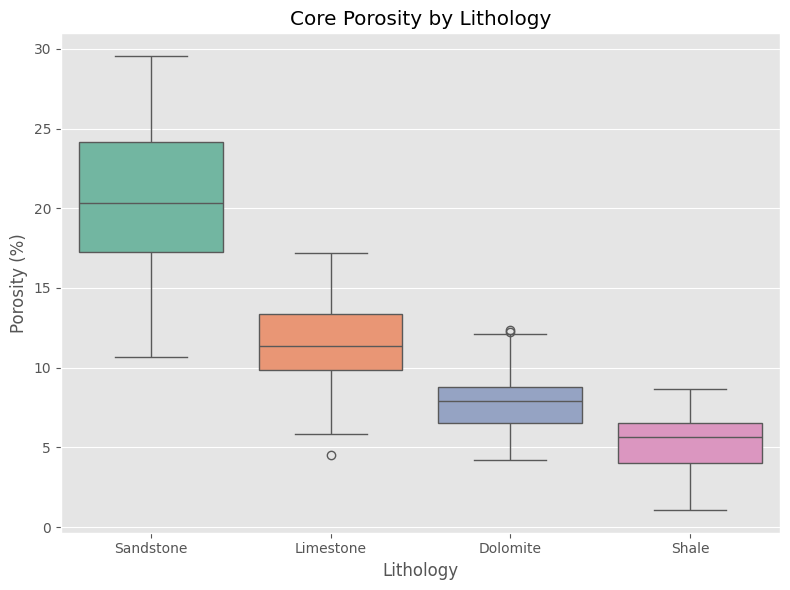

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Lithology', y='Porosity (%)', data=df_swarm,
            palette='Set2', ax=ax)
ax.set_title('Core Porosity by Lithology')
plt.tight_layout()
plt.show()

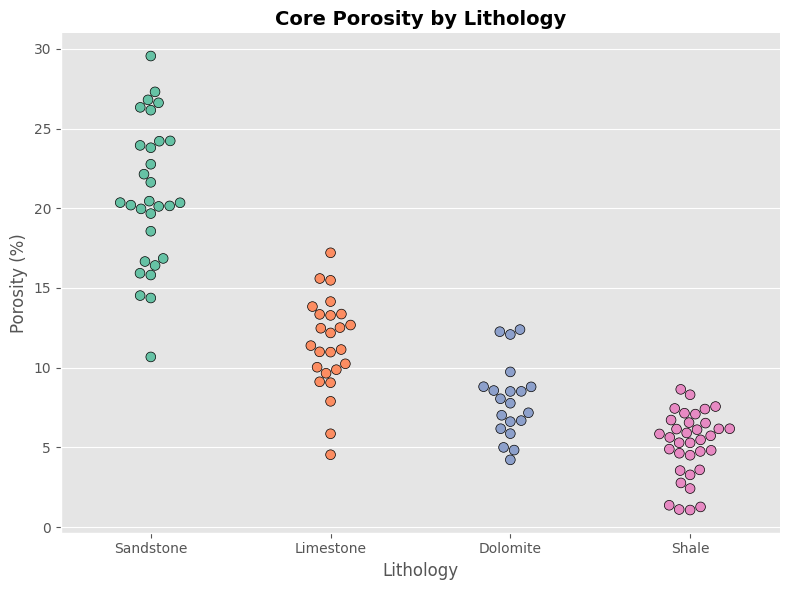

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.swarmplot(x='Lithology', y='Porosity (%)', data=df_swarm,
              palette='Set2', size=7, edgecolor='black',
              linewidth=0.5, ax=ax)
ax.set_title('Core Porosity by Lithology',
             fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

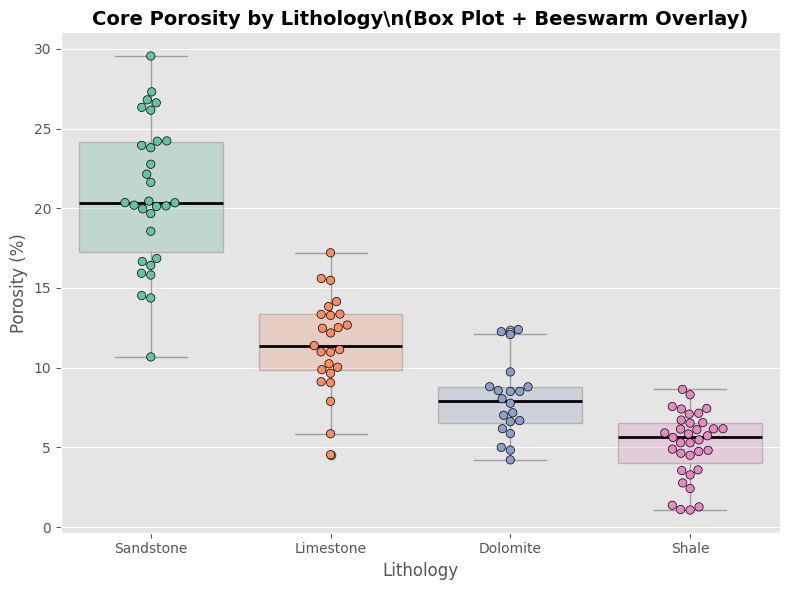

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(x='Lithology', y='Porosity (%)', data=df_swarm,
            palette='Set2', ax=ax,
            boxprops=dict(alpha=0.3),
            whiskerprops=dict(alpha=0.5),
            capprops=dict(alpha=0.5),
            medianprops=dict(color='black', linewidth=2))
sns.swarmplot(x='Lithology', y='Porosity (%)', data=df_swarm,
              palette='Set2', size=6, edgecolor='black',
              linewidth=0.5, ax=ax)
ax.set_title('Core Porosity by Lithology\\n(Box Plot + Beeswarm Overlay)',
             fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()